# Finite-shot quantum subspace expansion on H₂

This tutorial evaluates QSE matrices using simulated finite-shot
measurements. Start with the [statevector tutorial](qse_full_run.ipynb)
for the basic workflow.

The VQE reference is optimised using statevector expectations.
Shot noise is introduced only when measuring the QSE matrices;
hardware noise is not included.

## Imports

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

from qibochem.driver import Molecule
from qibochem.ansatz.ucc import Ansatz_UCCSD
from qibochem.measurement.protocol import StateVectorProtocol
from qibochem.selected_ci import QSE_Computable, generate_singlet_singles, solve_generalised_eigeneqn
import matplotlib.pyplot as plt
from qibochem.measurement.protocol import ShotMeasurementProtocol, MultiShotProtocol

## 1. Build the molecule

Create the same H₂/STO-3G molecule and run the Hartree–Fock
calculation with PySCF.

In [3]:
h2 = Molecule([
    ("H", (0.0, 0.0, 0.0)),
    ("H", (0.0, 0.0, 0.735)),
], basis="sto-3g")
h2.run_pyscf()

print(f"HF energy: {h2.e_hf:.12f} Ha")
print(f"Electrons: {h2.nelec}; spin orbitals: {h2.nso}")

HF energy: -1.116998996754 Ha
Electrons: 2; spin orbitals: 4


## 2. Optimise the UCCSD reference state

Optimise the UCCSD reference with `StateVectorProtocol()` and
retain the resulting circuit for all subsequent measurements.

In [4]:
protocol = StateVectorProtocol()
ansatz = Ansatz_UCCSD(
    mol=h2, 
    ferm_qubit_map="jw",
    trotter_steps=1,
    include_hf=True,
    use_mp2_guess=True
)

vqe_energy, vqe_params, final_circuit = ansatz.run_vqe(
    protocol=protocol, 
    method="L-BFGS-B", 
    fast=True
)

print(f"Ansatz parameters: {len(ansatz.param_names)}")
print(f"Circuit gates: {len(final_circuit.queue)}")
print(f"VQE energy: {vqe_energy:.12f} Ha")
print(vqe_params)

[Qibo 0.3.2|INFO|2026-09-22 11:10:55]: Using numpy backend on /CPU:0


Ansatz parameters: 3
Circuit gates: 198
VQE energy: -1.137306035753 Ha
{'s0': np.float64(-8.213539269144507e-09), 's1': np.float64(-8.213539269144507e-09), 'd0': np.float64(0.11176849986109837)}


## 3. Calculate the statevector QSE reference

Construct and solve the statevector QSE matrices using an overlap
cutoff of `1e-8`. These energies provide the reference for the
finite-shot errors reported below.

In [5]:
qse = QSE_Computable(
    molecule=h2, 
    excitation_generator=generate_singlet_singles, 
    observable=h2.hamiltonian("f"),
    spin_projection=0,
    ferm_qubit_map="jw", 
    map_threshold=1e-12,
)

H, S = qse.run_qse(
    circuit=final_circuit, 
    protocol=protocol
)

qse_energies, qse_vectors, qse_rank = solve_generalised_eigeneqn(H, S, threshold=1e-8)

print("H:")
print(np.real_if_close(H))
print("S:")
print(np.real_if_close(S))
print(f"Retained QSE rank: {qse_rank}")
print(f"QSE correction from VQE: {qse_energies[0] - vqe_energy:.12e} Ha")

H:
[[-4.41241293e+00  3.61708812e-08 -3.25037479e-09 -8.02176567e-02]
 [ 3.61708812e-08 -4.04938503e-03  3.60791195e-02  3.64809873e-10]
 [-3.25037479e-09  3.60791195e-02 -3.21456927e-01  4.39656254e-09]
 [-8.02176567e-02  3.64809873e-10  4.39656254e-09  2.36240997e-02]]
S:
[[ 3.95023894e+00 -3.08169505e-08 -1.63245801e-08  1.22124533e-14]
 [-3.08169505e-08  2.48805316e-02 -2.21680000e-01  1.83220963e-09]
 [-1.63245801e-08 -2.21680000e-01  1.97511947e+00 -1.26601608e-08]
 [ 1.22124533e-14  1.83220963e-09 -1.26601608e-08  4.97610632e-02]]
Retained QSE rank: 3
QSE correction from VQE: 1.953992523340e-14 Ha


## 4. Sample the QSE matrices

Pass a `ShotMeasurementProtocol` to `run_qse()` to obtain sampled
Hamiltonian and overlap matrices.

The protocol collects unique Pauli strings across both matrices
and groups them into qubit-wise commuting sets. Each group uses
one measurement basis. Basis rotations are applied to the
reference state, and sampled outcome counts are used to
reconstruct both matrices.

- `n_shots`: shots per commuting group, per repeat.
- `n_repeats`: number of independent sampled matrix pairs.
- `largest_first`: consider Pauli strings with more non-identity
  factors first during greedy grouping.

Using multiple repeats in one call shares the grouping, basis
rotations, and reconstruction setup. The example uses 10,000
shots per group and 10 repeats.

`H_samples` and `S_samples` are dictionaries with matching keys,
such as `shots_0`. Pair matrices using the same key to preserve
their shared measurement data.

In [6]:
shot_threshold = 1e-2
np.random.seed(42)
shot_protocol = ShotMeasurementProtocol(
    n_shots=10_000, 
    n_repeats=10,
    largest_first=True
)

H_samples, S_samples = qse.run_qse(final_circuit, shot_protocol)

records = []
# H_samples and S_samples are dictionaries with values of H and S matrices
for key, H_sample in H_samples.items():
    energies, _, rank = solve_generalised_eigeneqn(H_sample, S_samples[key], threshold=shot_threshold)
    s0 = energies[0]
    s1 = energies[1] if rank > 1 else np.nan
    records.append({
        "sample": key, "repeat": int(key.rsplit("_", 1)[1]), "retained_rank": rank,
        "s0_energy_Ha": s0, "s1_energy_Ha": s1,
        "s0_error_mHa": 1000 * abs(s0 - qse_energies[0]),
        "s1_error_mHa": 1000 * abs(s1 - qse_energies[1]),
    })
df_shot_errors = pd.DataFrame(records)

display(df_shot_errors)

,sample,repeat,retained_rank,s0_energy_Ha,s1_energy_Ha,s0_error_mHa,s1_error_mHa
0,shots_0,0,3,-1.138343,-0.162591,1.036635,0.161718
1,shots_1,1,3,-1.135916,-0.164257,1.389786,1.503902
2,shots_2,2,3,-1.137526,-0.163617,0.219553,0.863884
3,shots_3,3,3,-1.135547,-0.161814,1.758928,0.939639
4,shots_4,4,3,-1.139841,-0.164180,2.535202,1.427002
5,shots_5,5,3,-1.138145,-0.164501,0.839345,1.748128
6,shots_6,6,3,-1.141934,-0.163062,4.628263,0.308854
7,shots_7,7,3,-1.139712,-0.165757,2.406409,3.004007
8,shots_8,8,3,-1.141503,-0.164890,4.196841,2.136374
9,shots_9,9,3,-1.139722,-0.164727,2.415943,1.973536


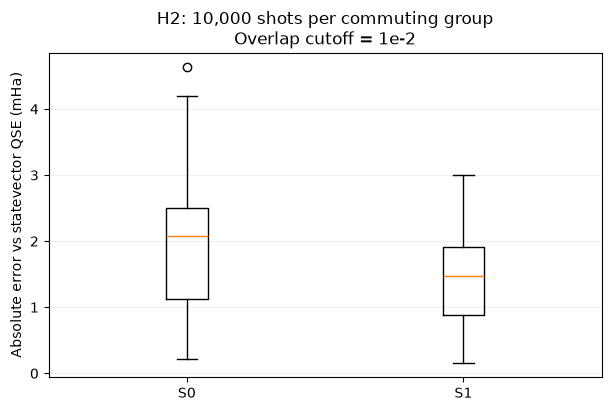

In [7]:
figure, axis = plt.subplots(figsize=(6, 4), layout="constrained")
axis.boxplot(
    [df_shot_errors[f"{state}_error_mHa"].dropna() for state in ("s0", "s1")],
    tick_labels=["S0", "S1"],
)
axis.set_ylabel("Absolute error vs statevector QSE (mHa)")
axis.set_title("H2: 10,000 shots per commuting group\nOverlap cutoff = 1e-2")
axis.grid(axis="y", alpha=0.2)
plt.show()

## 5. Compare multiple shot counts

Use `MultiShotProtocol` to evaluate several shot counts within
one grouped measurement setup.

- `sample_sizes`: shot counts per commuting group. This is a tuple of integers, MultiShotProtocol evaluates all of them.
- `n_repeats`: independent repeats for each shot count.
- `largest_first`: the same grouping option used above.

This example uses 1,000, 10,000, and 100,000 shots per group,
with 10 repeats at each count. Returned dictionary keys follow
`shots_{n_shots}_{repeat}`, for example `shots_10000_0`.
Repeat indices start at zero.

Both sampling protocols draw outcome counts directly from a
multinomial distribution. This avoids constructing an explicit
list of individual measurement outcomes while reproducing the
count distribution of independent measurements.

The final plots compare S0 and S1 error distributions across
shot counts using the same `1e-2` overlap cutoff. The logarithmic
error axis keeps both small errors and large outliers visible.

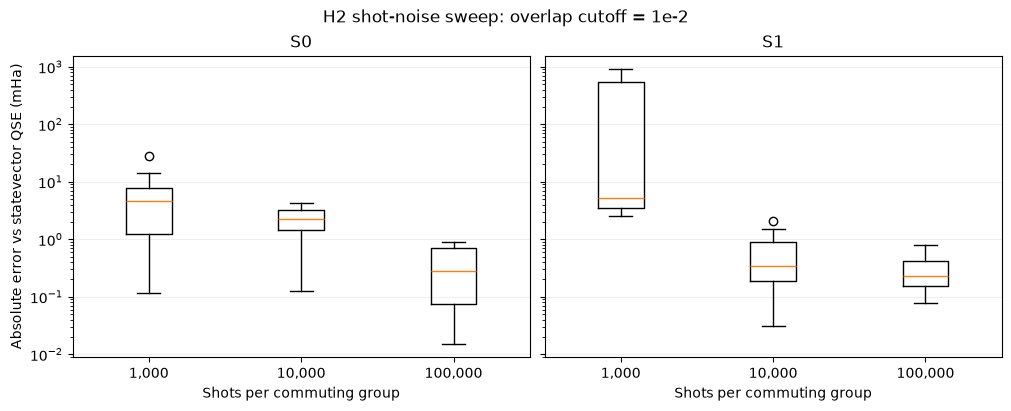

In [10]:
np.random.seed(42)
multi_protocol = MultiShotProtocol(
    sample_sizes=(1_000, 10_000, 100_000), 
    n_repeats=10,
    largest_first=True
)

H_sweep, S_sweep = qse.run_qse(final_circuit, multi_protocol)

records = []
for key, H_sample in H_sweep.items():
    energies, _, rank = solve_generalised_eigeneqn(H_sample, S_sweep[key], threshold=shot_threshold)
    _, n_shots, repeat = key.split("_")
    s0 = energies[0]
    s1 = energies[1] if rank > 1 else np.nan
    records.append({
        "sample": key, "n_shots": int(n_shots), "repeat": int(repeat), 
        "s0_energy_Ha": s0, "s1_energy_Ha": s1,
        "s0_error_mHa": 1000 * abs(s0 - qse_energies[0]),
        "s1_error_mHa": 1000 * abs(s1 - qse_energies[1]),
    })
df_shot_sweep = pd.DataFrame(records)

figure, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, layout="constrained")
for axis, state in zip(axes, ("s0", "s1")):
    distributions = [
        df_shot_sweep.loc[df_shot_sweep["n_shots"] == shots, f"{state}_error_mHa"].dropna()
        for shots in multi_protocol.sample_sizes
    ]
    axis.boxplot(distributions, tick_labels=[f"{shots:,}" for shots in multi_protocol.sample_sizes])
    axis.set_title(state.upper())
    axis.set_yscale("log")
    axis.set_xlabel("Shots per commuting group")
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Absolute error vs statevector QSE (mHa)")
figure.suptitle("H2 shot-noise sweep: overlap cutoff = 1e-2")
plt.show()